In [1]:
# Caso ainda não tenha instalado, descomente a linha abaixo:
# !pip install basedosdados pandas matplotlib seaborn scikit-learn

import basedosdados as bd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão para os gráficos do notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# SUBSTITUA pelo seu Project ID do Google Cloud
billing_id = "portfolio-educacao-sql"  # <- coloque aqui o seu Project ID do Google Cloud

query = """
SELECT
  dados.ano as ano,
  dados.id_municipio AS id_municipio,
  diretorio_id_municipio.nome AS id_municipio_nome,
  dados.localizacao as localizacao,
  dados.atu_ef as atu_ef,
  dados.atu_em as atu_em,
  dados.had_ef as had_ef,
  dados.had_em as had_em,
  dados.taxa_aprovacao_ef as taxa_aprovacao_ef,
  dados.taxa_aprovacao_em as taxa_aprovacao_em,
  dados.taxa_reprovacao_ef as taxa_reprovacao_ef,
  dados.taxa_abandono_em as taxa_abandono_em
FROM `basedosdados.br_inep_indicadores_educacionais.municipio` AS dados
LEFT JOIN (
  SELECT DISTINCT id_municipio, nome
  FROM `basedosdados.br_bd_diretorios_brasil.municipio`
) AS diretorio_id_municipio
ON dados.id_municipio = diretorio_id_municipio.id_municipio
"""

df = bd.read_sql(query=query, billing_project_id=billing_id)
print(df.shape)
df.head()

Downloading: 100%|██████████|
(1277948, 12)


,ano,id_municipio,id_municipio_nome,localizacao,atu_ef,atu_em,had_ef,had_em,taxa_aprovacao_ef,taxa_aprovacao_em,taxa_reprovacao_ef,taxa_abandono_em
0,2020,1506104,Primavera,rural,17.6,NaN,7.3,NaN,NaN,NaN,NaN,NaN
1,2020,1506104,Primavera,rural,17.6,NaN,7.3,NaN,NaN,NaN,NaN,NaN
2,2020,1506104,Primavera,rural,17.6,NaN,7.3,NaN,NaN,NaN,NaN,NaN
3,2020,1709302,Guaraí,rural,13.9,NaN,7.3,NaN,NaN,NaN,NaN,NaN
4,2020,1709302,Guaraí,rural,13.9,NaN,7.3,NaN,NaN,NaN,NaN,NaN


In [3]:
#salvando localmente para não precisar consultar o BigQuery novamente
df.to_csv("indicadores_educacionais_municipio.csv", index=False)

In [4]:
df = pd.read_csv("indicadores_educacionais_municipio.csv") 

In [5]:
#baixando as UFs e região de cada código dos mun
query_municipios = """
SELECT
  id_municipio,
  sigla_uf,
  nome AS nome_municipio
FROM `basedosdados.br_bd_diretorios_brasil.municipio`
"""

municipios = bd.read_sql(query=query_municipios, billing_project_id=billing_id)
municipios.head()

Downloading: 100%|██████████|


,id_municipio,sigla_uf,nome_municipio
0,5101837,MT,Boa Esperança do Norte
1,1101104,RO,Itapuã do Oeste
2,1100205,RO,Porto Velho
3,1100809,RO,Candeias do Jamari
4,1100338,RO,Nova Mamoré


In [6]:
# Mapeamento de sigla da UF para Região
mapa_regiao = {
    'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste',
    'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

municipios['regiao'] = municipios['sigla_uf'].map(mapa_regiao)

# Padronizando id_municipio nos dois dataframes
df['id_municipio'] = df['id_municipio'].astype(str)
municipios['id_municipio'] = municipios['id_municipio'].astype(str)

# Juntando com o dataframe principal
df = df.merge(
    municipios[['id_municipio', 'sigla_uf', 'regiao']],
    on='id_municipio',
    how='left'
)

df.head()

,ano,id_municipio,id_municipio_nome,localizacao,atu_ef,atu_em,had_ef,had_em,taxa_aprovacao_ef,taxa_aprovacao_em,taxa_reprovacao_ef,taxa_abandono_em,sigla_uf,regiao
0,2020,1506104,Primavera,rural,17.6,NaN,7.3,NaN,NaN,NaN,NaN,NaN,PA,Norte
1,2020,1506104,Primavera,rural,17.6,NaN,7.3,NaN,NaN,NaN,NaN,NaN,PA,Norte
2,2020,1506104,Primavera,rural,17.6,NaN,7.3,NaN,NaN,NaN,NaN,NaN,PA,Norte
3,2020,1709302,Guaraí,rural,13.9,NaN,7.3,NaN,NaN,NaN,NaN,NaN,TO,Norte
4,2020,1709302,Guaraí,rural,13.9,NaN,7.3,NaN,NaN,NaN,NaN,NaN,TO,Norte


In [7]:
df = df.dropna()
df.head()

,ano,id_municipio,id_municipio_nome,localizacao,atu_ef,atu_em,had_ef,had_em,taxa_aprovacao_ef,taxa_aprovacao_em,taxa_reprovacao_ef,taxa_abandono_em,sigla_uf,regiao
100333,2019,1100122,Ji-Paraná,rural,14.1,19.7,5.8,7.4,85.9,88.9,13.7,0.5,RO,Norte
100334,2019,1300631,Beruri,rural,17.8,19.7,4.0,4.3,84.0,82.3,8.8,2.1,AM,Norte
100335,2019,1300631,Beruri,rural,17.8,19.7,4.0,4.3,84.0,82.3,8.8,2.1,AM,Norte
100336,2019,1301001,Carauari,total,27.3,24.8,5.5,5.1,94.1,90.8,4.8,2.4,AM,Norte
100337,2019,1301852,Iranduba,rural,31.7,19.6,5.6,4.3,94.4,83.0,4.4,12.7,AM,Norte


In [8]:
print(f"Total de linhas: {len(df):,}")
print(f"Municípios sem região mapeada: {df['regiao'].isna().sum()}")
print(f"Período: {df['ano'].min()} a {df['ano'].max()}")
df['regiao'].value_counts()

Total de linhas: 507,943
Municípios sem região mapeada: 0
Período: 2010 a 2024


regiao
Nordeste        158658
Sudeste         151583
Sul             108520
Centro-Oeste     44994
Norte            44188
Name: count, dtype: int64

# Análise Exploratória
- Quais foram as porcentagens de aprovação, reprovação e abandono escolar ao longo dos anos?
- Existe diferença desses indicadores entre as regiões?
- Existe diferença relevante entre zona urbana e rural?
- Turmas maiores impactam a taxa de aprovação?

In [9]:
# drop dos anos de 2023 e 2024
df = df[~df['ano'].isin([2023,2024])]

In [10]:
# Médias por região
ultimo_ano = df['ano'].max()
recentes = df[df['ano'] >= ultimo_ano - 4]

medias_regiao = recentes.groupby('regiao')[
    ['taxa_aprovacao_ef', 'taxa_aprovacao_em', 'taxa_abandono_em']
].mean().sort_values('taxa_abandono_em', ascending=False)

medias_regiao

,taxa_aprovacao_ef,taxa_aprovacao_em,taxa_abandono_em
regiao,,,
Norte,90.674308,84.867387,8.224419
Nordeste,90.793819,86.475567,6.918729
Sul,93.660757,87.064968,5.268641
Centro-Oeste,96.033576,87.305364,4.611527
Sudeste,95.500142,90.803676,3.844055


In [11]:
# Evolução nacional média ao longo dos anos
evolucao_nacional = df.groupby('ano')[
    ['taxa_aprovacao_ef', 'taxa_aprovacao_em', 'taxa_reprovacao_ef', 'taxa_abandono_em']
].mean()

evolucao_nacional

,taxa_aprovacao_ef,taxa_aprovacao_em,taxa_reprovacao_ef,taxa_abandono_em
ano,,,,
2010,86.734271,81.375208,9.822886,9.816708
2011,87.734220,81.715294,9.236012,9.194696
2012,88.380553,82.427075,8.714529,8.956695
2013,89.612418,83.355692,7.999033,7.899221
2014,89.387442,83.093914,8.316454,7.451589
2015,89.641870,83.636840,8.185263,7.239125
2016,89.247224,83.421057,8.644334,6.819184
2017,90.416487,84.401180,7.701891,6.583471
2018,90.682019,84.430067,7.625941,6.422669


In [12]:
# Correlação entre alunos por turma (atu) e taxa de aprovação
correlacao = df[['atu_ef', 'atu_em', 'taxa_aprovacao_ef', 'taxa_aprovacao_em']].corr()
correlacao

,atu_ef,atu_em,taxa_aprovacao_ef,taxa_aprovacao_em
atu_ef,1.000000,0.571937,-0.173402,-0.141773
atu_em,0.571937,1.000000,-0.200358,-0.236759
taxa_aprovacao_ef,-0.173402,-0.200358,1.000000,0.541934
taxa_aprovacao_em,-0.141773,-0.236759,0.541934,1.000000


# Visualizações 
- Temporal
- Entre regiões
- Urbano/Rural
- Relação entre alunos e aprovação

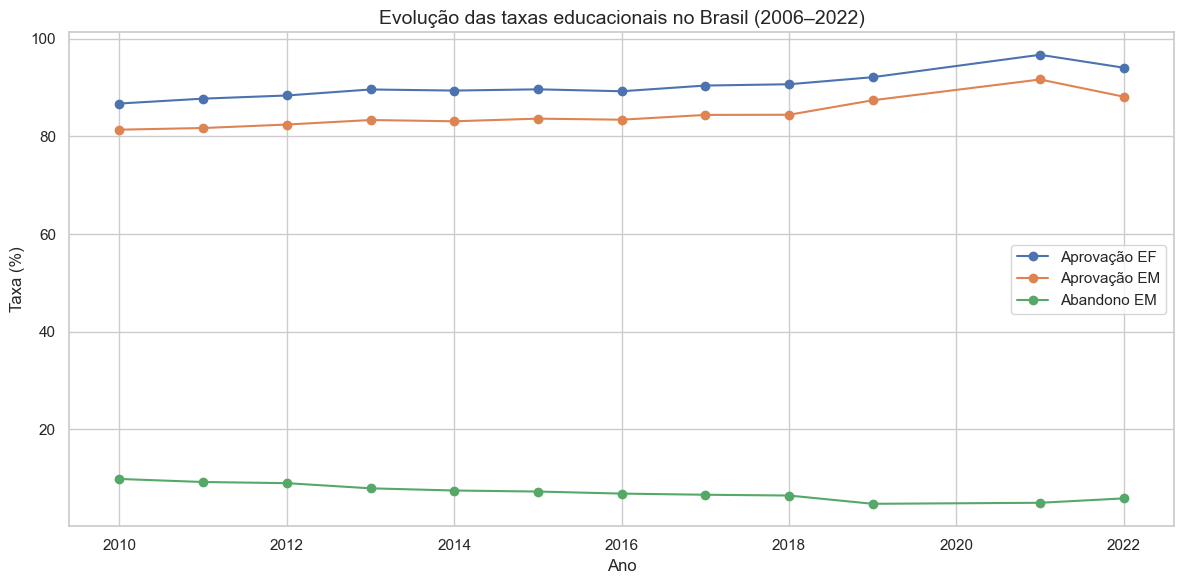

In [13]:
# Evolução temporal das taxas

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(evolucao_nacional.index, evolucao_nacional['taxa_aprovacao_ef'], label='Aprovação EF', marker='o')
ax.plot(evolucao_nacional.index, evolucao_nacional['taxa_aprovacao_em'], label='Aprovação EM', marker='o')
ax.plot(evolucao_nacional.index, evolucao_nacional['taxa_abandono_em'], label='Abandono EM', marker='o')

ax.set_title('Evolução das taxas educacionais no Brasil (2006–2022)', fontsize=14)
ax.set_xlabel('Ano')
ax.set_ylabel('Taxa (%)')
ax.legend()
plt.tight_layout()
plt.savefig('evolucao_temporal.png', dpi=150)
plt.show()

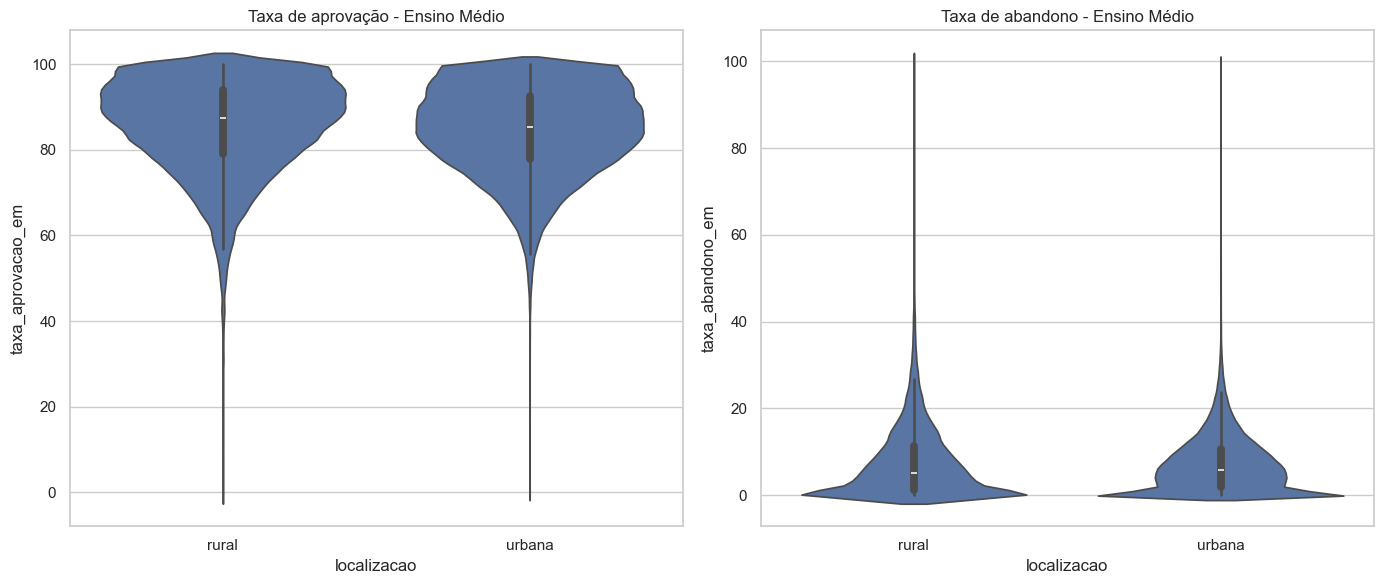

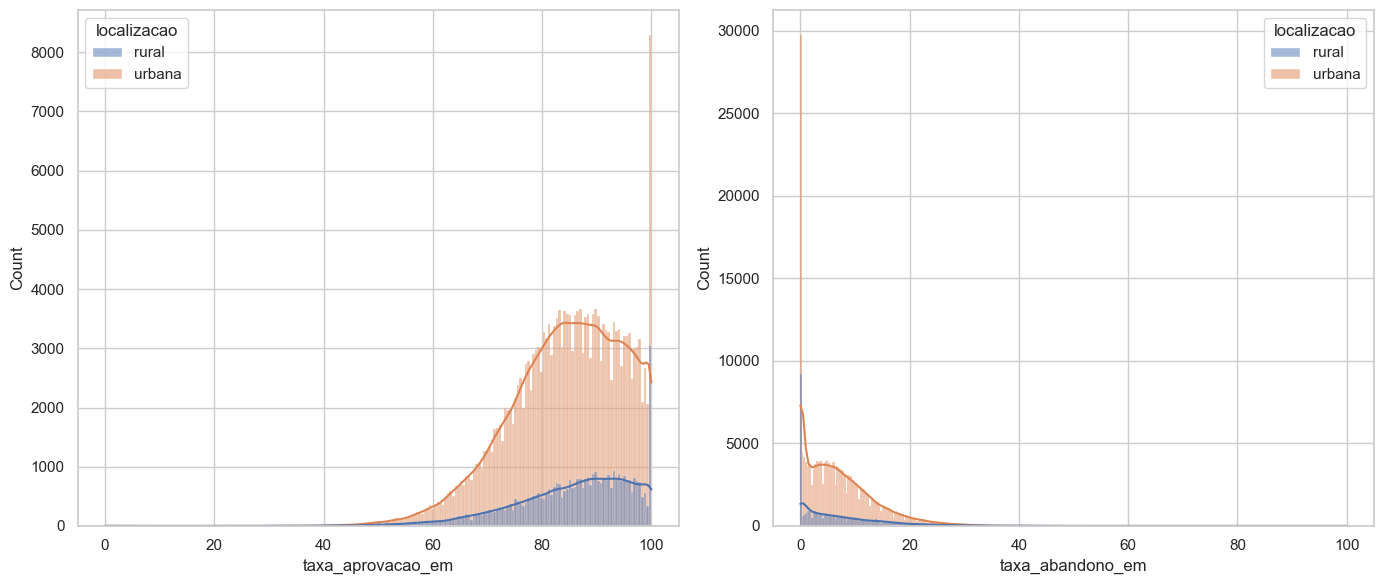

In [14]:
# Urbano/Rural
df = df[df['localizacao'] != 'total']

#comparação entre áreas rurais e urbanas para ensino médio, 
#caso queira modificar para ensino fundamental, mude por exemplo em "y='taxa_abandono_em'" para "y='taxa_abandono_ef'"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(data=df, x='localizacao', y='taxa_aprovacao_em', ax=axes[0])
axes[0].set_title('Taxa de aprovação - Ensino Médio')

sns.violinplot(data=df, x='localizacao', y='taxa_abandono_em', ax=axes[1])
axes[1].set_title('Taxa de abandono - Ensino Médio')

plt.tight_layout()
plt.show()

#histograma
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(
    data=df,
    x='taxa_aprovacao_em',
    hue='localizacao',
    kde=True,
    ax=axes[0]
)

sns.histplot(
    data=df,
    x='taxa_abandono_em',
    hue='localizacao',
    kde=True,
    ax=axes[1]
)

plt.tight_layout()
plt.show()

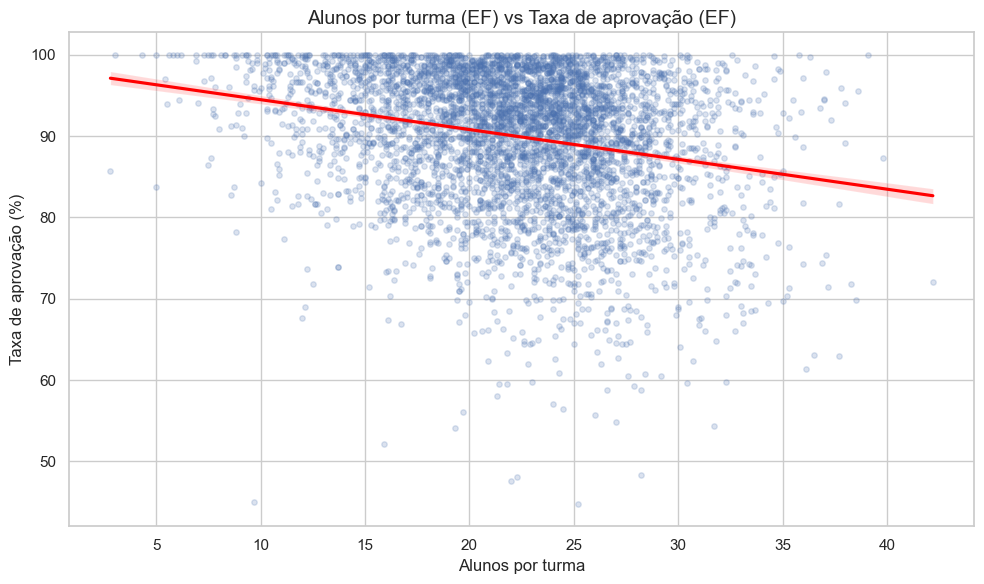

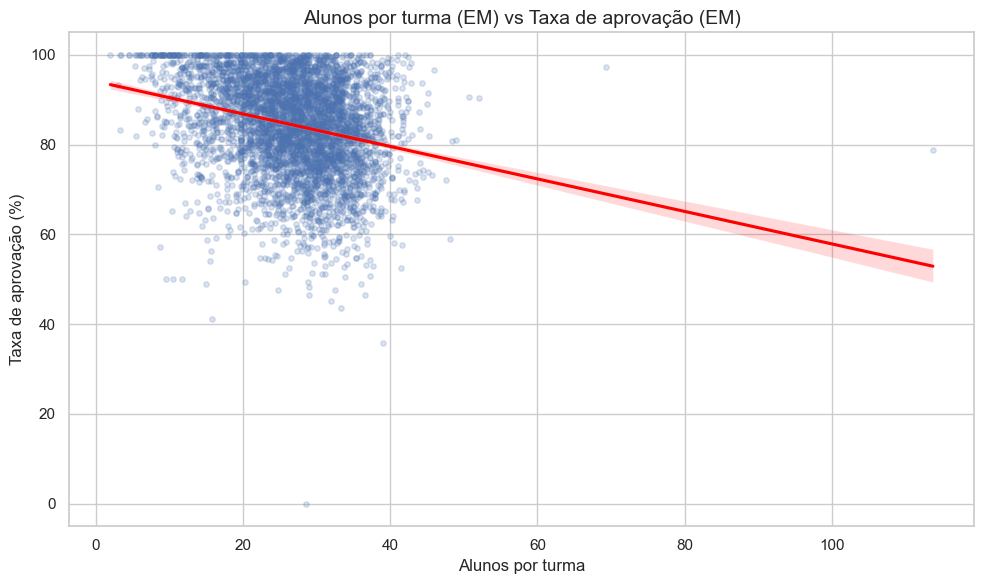

In [15]:
#relação alunos por turma e aprovação

# turmas mais cheias possuem uma taxa de aprovação menor?
fig, ax = plt.subplots(figsize=(10, 6))

amostra = df.dropna(subset=['atu_ef', 'taxa_aprovacao_ef']).sample(
    n=min(5000, df.dropna(subset=['atu_ef', 'taxa_aprovacao_ef']).shape[0]),
    random_state=42
)

sns.regplot(data=amostra, x='atu_ef', y='taxa_aprovacao_ef',
            scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'color': 'red'}, ax=ax)

ax.set_title('Alunos por turma (EF) vs Taxa de aprovação (EF)', fontsize=14)
ax.set_xlabel('Alunos por turma')
ax.set_ylabel('Taxa de aprovação (%)')
plt.tight_layout()
plt.savefig('scatter_atu_aprovacao_ef.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

amostra = df.dropna(subset=['atu_em', 'taxa_aprovacao_em']).sample(
    n=min(5000, df.dropna(subset=['atu_em', 'taxa_aprovacao_em']).shape[0]),
    random_state=42
)

sns.regplot(data=amostra, x='atu_em', y='taxa_aprovacao_em',
            scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'color': 'red'}, ax=ax)

ax.set_title('Alunos por turma (EM) vs Taxa de aprovação (EM)', fontsize=14)
ax.set_xlabel('Alunos por turma')
ax.set_ylabel('Taxa de aprovação (%)')
plt.tight_layout()
plt.savefig('scatter_atu_aprovacao_em.png', dpi=150)
plt.show()


# Modelo preditivo 
 - Prevendo a taxa de aprovação no Ensino Médio
 - A intenção é prever `taxa_aprovacao_em` a partir de variáveis estruturais (alunos por turma, horas-aula, região, localização, ano). A partir do **Random Forest Regressor**, que lida bem com relações não-lineares e nos dá `feature_importance` — útil para discutir *o que mais impacta* a aprovação, e não só prever o número.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features e target
features_numericas = ['atu_em', 'had_em', 'ano']
features_categoricas = ['regiao', 'localizacao']
target = 'taxa_aprovacao_em'

colunas_modelo = features_numericas + features_categoricas + [target]
dados_modelo = df[colunas_modelo].dropna()

print(f"Número de linhas disponíveis para o modelo: {len(dados_modelo):,} (de {len(df):,} totais)")

X = dados_modelo[features_numericas + features_categoricas]
y = dados_modelo[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Número de linhas disponíveis para o modelo: 247,636 (de 247,636 totais)


# Pipeline e treinamento
 - `Pipeline` com `ColumnTransformer` para tratar variáveis categóricas (região, localização) automaticamente via One-Hot Encoding, mantendo o código limpo e reprodutível.

In [17]:
preprocessador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_categoricas)
    ],
    remainder='passthrough'  # mantém as colunas numéricas como estão
)

modelo = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
])

modelo.fit(X_train, y_train)

,steps,"[('preprocessador', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
# avaliação do modelo
y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} pontos percentuais")
print(f"R²: {r2:.3f}")


MAE: 6.41 pontos percentuais
R²: 0.377


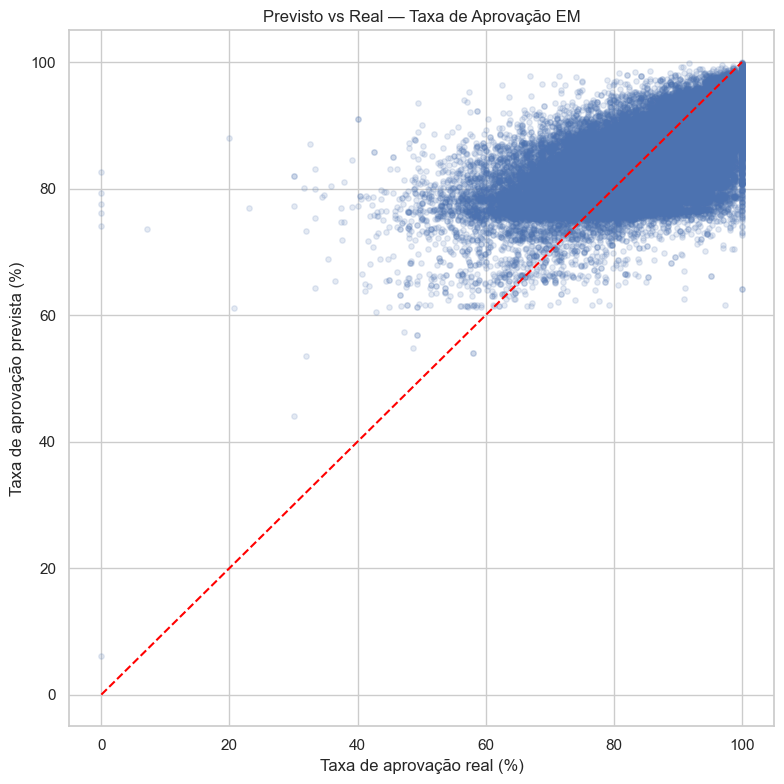

In [19]:
# Visualizando previsto vs real
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.15, s=15)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
ax.set_xlabel('Taxa de aprovação real (%)')
ax.set_ylabel('Taxa de aprovação prevista (%)')
ax.set_title('Previsto vs Real — Taxa de Aprovação EM')
plt.tight_layout()
plt.savefig('previsto_vs_real.png', dpi=150)
plt.show()

- Quais fatores o modelo considerou mais relevante para prever a aprovação?

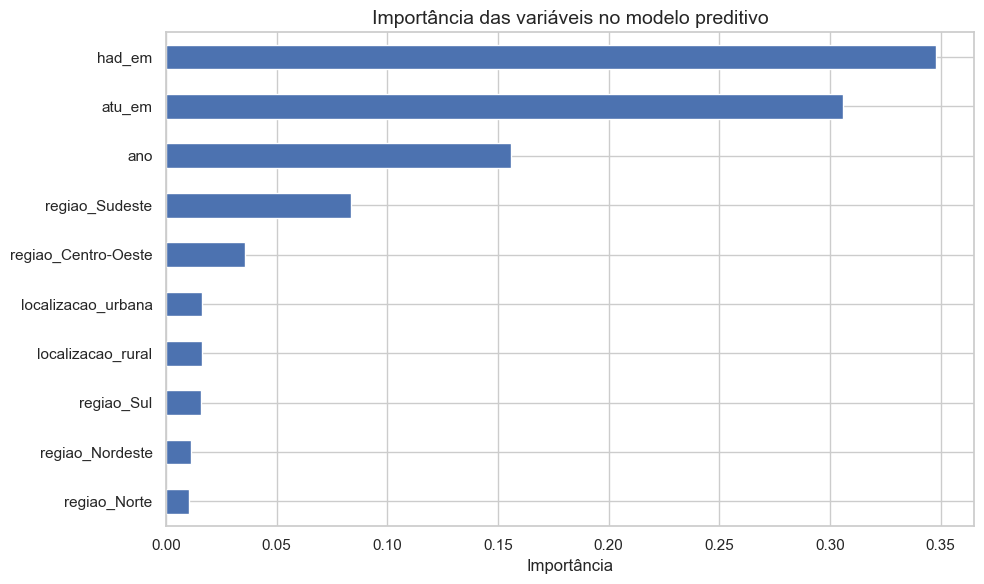

In [20]:
# Extraindo nomes das features após o One-Hot Encoding
nomes_categoricas = modelo.named_steps['preprocessador'].named_transformers_['cat'].get_feature_names_out(features_categoricas)
nomes_features = list(nomes_categoricas) + features_numericas

importancias = pd.Series(
    modelo.named_steps['regressor'].feature_importances_,
    index=nomes_features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importancias.plot(kind='barh', ax=ax)
ax.set_title('Importância das variáveis no modelo preditivo', fontsize=14)
ax.set_xlabel('Importância')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


# Mapa 
- Escolhi a Região Metropolitana para visualização das informações da taxa de aprovação do ensino médio e fundamental
- informação importante: O `id_municipio` já está em código IBGE (confirmado na carga original), então o merge com a geometria é direto, sem precisar de nome.

In [21]:
# !pip install geopandas plotly mapclassify shapely

import geopandas as gpd
import plotly.express as px
from shapely import wkt

# São 29 municípios na RMC
nomes_rmc = [
    'Curitiba', 'Adrianópolis', 'Agudos do Sul', 'Almirante Tamandaré', 'Araucária',
    'Balsa Nova', 'Bocaiúva do Sul', 'Campina Grande do Sul', 'Campo do Tenente',
    'Campo Largo', 'Campo Magro', 'Cerro Azul', 'Colombo', 'Contenda', 'Doutor Ulysses',
    'Fazenda Rio Grande', 'Itaperuçu', 'Lapa', 'Mandirituba', 'Piên', 'Pinhais',
    'Piraquara', 'Quatro Barras', 'Quitandinha', 'Rio Branco do Sul', 'Rio Negro',
    'São José dos Pinhais', 'Tijucas do Sul', 'Tunas do Paraná'
]

query_validacao = """
SELECT id_municipio, nome, sigla_uf
FROM `basedosdados.br_bd_diretorios_brasil.municipio`
WHERE sigla_uf = 'PR'
"""

municipios_pr = bd.read_sql(query=query_validacao, billing_project_id=billing_id)
validacao_rmc = municipios_pr[municipios_pr['nome'].isin(nomes_rmc)]

print(f"Encontrados: {len(validacao_rmc)} de {len(nomes_rmc)} esperados")
faltantes = set(nomes_rmc) - set(validacao_rmc['nome'])
if faltantes:
    print("Não encontrados (cheque grafia/acentuação):", faltantes)

codigos_rmc = validacao_rmc['id_municipio'].tolist()
validacao_rmc

Downloading: 100%|██████████|
Encontrados: 29 de 29 esperados


,id_municipio,nome,sigla_uf
362,4105201,Cerro Azul,PR
363,4128633,Doutor Ulysses,PR
364,4100202,Adrianópolis,PR
365,4113205,Lapa,PR
367,4127882,Tunas do Paraná,PR
368,4104006,Campina Grande do Sul,PR
369,4120804,Quatro Barras,PR
370,4100400,Almirante Tamandaré,PR
371,4119152,Pinhais,PR
372,4119509,Piraquara,PR


In [22]:
query_colunas = """
SELECT column_name, data_type
FROM `basedosdados.br_bd_diretorios_brasil.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'municipio'
"""

colunas_municipio = bd.read_sql(query=query_colunas, billing_project_id=billing_id)
colunas_municipio

Downloading: 100%|██████████|


,column_name,data_type
0,id_municipio,STRING
1,id_municipio_6,STRING
2,id_municipio_tse,STRING
3,id_municipio_rf,STRING
4,id_municipio_bcb,STRING
5,nome,STRING
6,capital_uf,INT64
7,id_comarca,STRING
8,id_regiao_saude,STRING
9,nome_regiao_saude,STRING


In [23]:
query_colunas_geobr = """
SELECT column_name, data_type
FROM `basedosdados.br_geobr_mapas.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'municipio'
"""

colunas_geobr = bd.read_sql(query=query_colunas_geobr, billing_project_id=billing_id)
colunas_geobr

Downloading: 100%|██████████|


,column_name,data_type
0,id_municipio,STRING
1,sigla_uf,STRING
2,geometria,GEOGRAPHY


In [24]:
query_geo = """
SELECT
  id_municipio,
  ST_ASTEXT(geometria) AS geometria_wkt
FROM `basedosdados.br_geobr_mapas.municipio`
WHERE sigla_uf = 'PR'
"""

geo_pr = bd.read_sql(query=query_geo, billing_project_id=billing_id)

geo_pr['geometry'] = geo_pr['geometria_wkt'].apply(wkt.loads)
gdf_pr = gpd.GeoDataFrame(geo_pr, geometry='geometry', crs='EPSG:4326')

gdf_rmc = gdf_pr[gdf_pr['id_municipio'].isin(codigos_rmc)].copy()
print(f"Municípios encontrados na geometria: {len(gdf_rmc)} de {len(codigos_rmc)} esperados")

Downloading: 100%|██████████|
Municípios encontrados na geometria: 29 de 29 esperados


In [25]:
ultimo_ano_mapa = df['ano'].max()

dados_rmc = (
    df[(df['id_municipio'].astype(str).isin(gdf_rmc['id_municipio'])) & (df['ano'] == ultimo_ano_mapa)]
    .groupby('id_municipio')[['taxa_aprovacao_ef', 'taxa_aprovacao_em']]
    .mean()
    .reset_index()
)
dados_rmc['id_municipio'] = dados_rmc['id_municipio'].astype(str)

# Trazendo o nome do município de volta (não existe na tabela de geometria)
mapa_rmc = gdf_rmc.merge(dados_rmc, on='id_municipio', how='left')
mapa_rmc = mapa_rmc.merge(validacao_rmc[['id_municipio', 'nome']], on='id_municipio', how='left')

print(f"Ano de referência: {ultimo_ano_mapa}")
mapa_rmc[['id_municipio', 'nome', 'taxa_aprovacao_ef', 'taxa_aprovacao_em']]

Ano de referência: 2022


,id_municipio,nome,taxa_aprovacao_ef,taxa_aprovacao_em
0,4122206,Rio Branco do Sul,96.183333,88.800000
1,4121208,Quitandinha,98.183333,96.300000
2,4114302,Mandirituba,96.150000,92.000000
3,4100202,Adrianópolis,99.616667,96.450000
4,4120804,Quatro Barras,93.725000,91.775000
5,4122305,Rio Negro,96.857143,95.285714
6,4102307,Balsa Nova,93.966667,93.400000
7,4104253,Campo Magro,89.350000,80.550000
8,4119152,Pinhais,95.750000,88.550000
9,4104204,Campo Largo,96.071429,94.214286


# Mapa

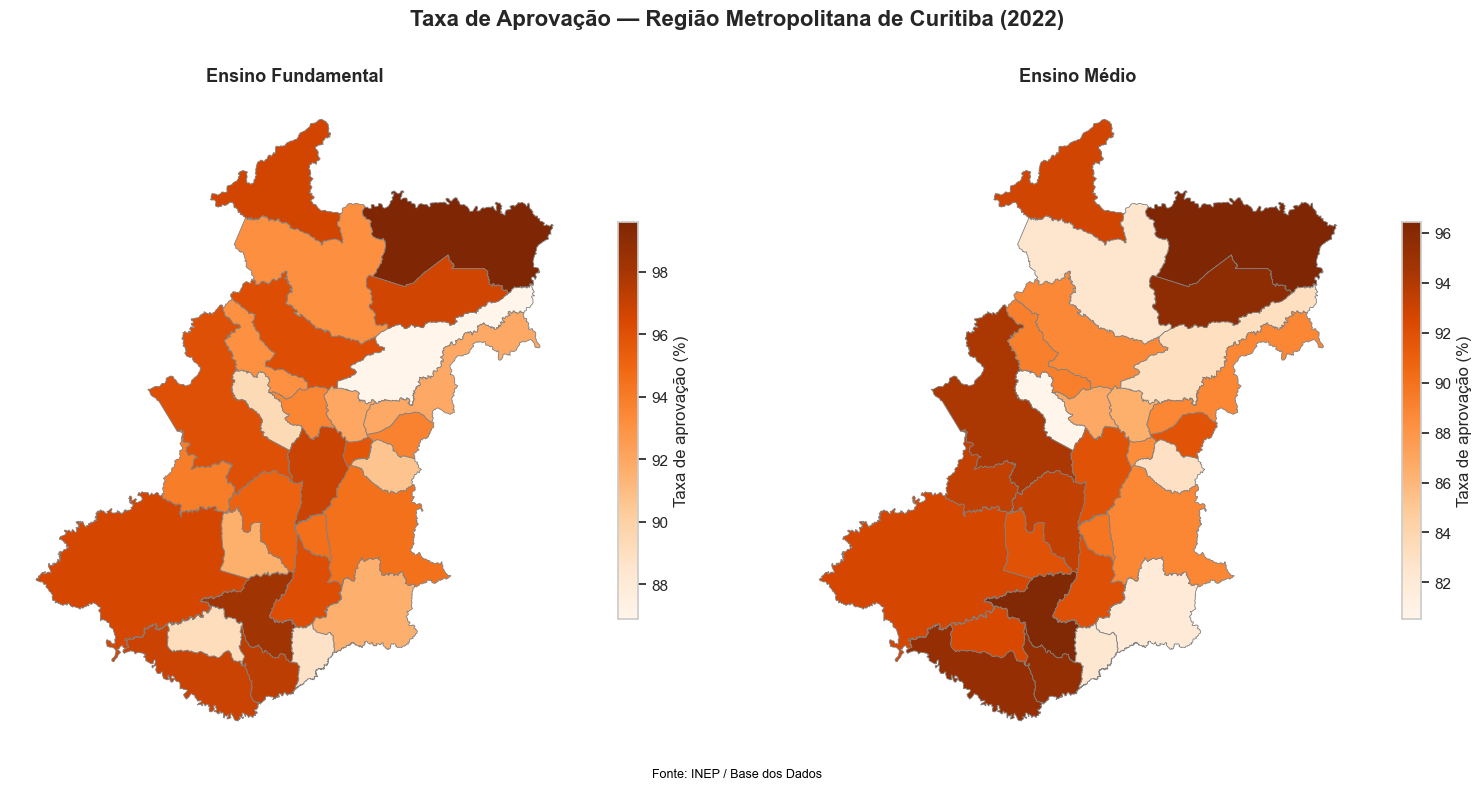

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, coluna, titulo in zip(
    axes,
    ['taxa_aprovacao_ef', 'taxa_aprovacao_em'],
    ['Ensino Fundamental', 'Ensino Médio']
):
    mapa_rmc.plot(
        column=coluna,
        ax=ax,
        cmap='Oranges',
        edgecolor='gray',
        linewidth=0.6,
        legend=True,
        legend_kwds={'label': 'Taxa de aprovação (%)', 'shrink': 0.6},
        missing_kwds={'color': 'lightgrey', 'label': 'Sem dado'}
    )
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_axis_off()

fig.suptitle(
    f'Taxa de Aprovação — Região Metropolitana de Curitiba ({ultimo_ano_mapa})',
    fontsize=16, fontweight='bold', y=0.98
)
fig.text(0.5, 0.02, 'Fonte: INEP / Base dos Dados', ha='center', fontsize=9, color='black')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('mapa_rmc_aprovacao_estatico.png', dpi=200, bbox_inches='tight')
plt.show()


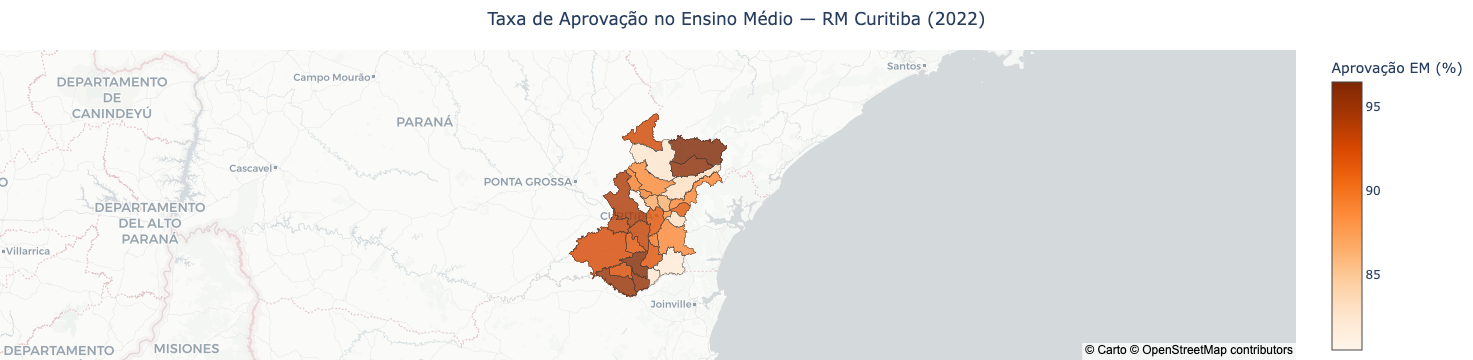

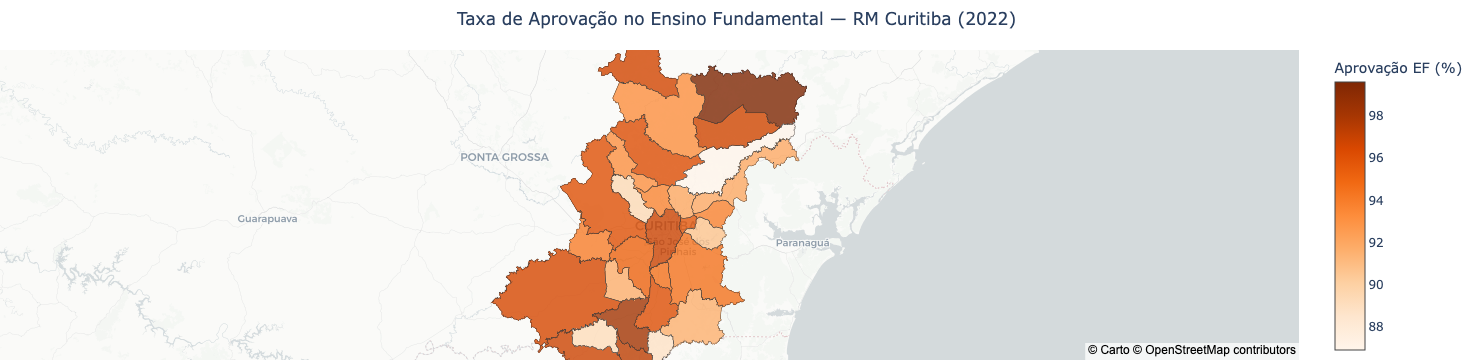

In [30]:
import json

geojson_rmc = json.loads(mapa_rmc.to_json())
import plotly.graph_objects as go

minx, miny, maxx, maxy = mapa_rmc.total_bounds
centro_lat = (miny + maxy) / 2
centro_lon = (minx + maxx) / 2

fig_em = go.Figure(go.Choroplethmapbox(
    geojson=geojson_rmc,
    locations=mapa_rmc.index,
    z=mapa_rmc['taxa_aprovacao_em'],
    colorscale='Oranges',
    marker_opacity=0.8,
    marker_line_width=0.5,
    customdata=mapa_rmc[['nome', 'taxa_aprovacao_ef', 'taxa_aprovacao_em']],
    hovertemplate='<b>%{customdata[0]}</b><br>Aprovação EF: %{customdata[1]:.1f}%<br>Aprovação EM: %{customdata[2]:.1f}%<extra></extra>',
    colorbar_title='Aprovação EM (%)'
))

fig_em.update_layout(
    mapbox_style='carto-positron',
    mapbox_zoom=6,
    mapbox_center={'lat': centro_lat, 'lon': centro_lon},
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    title=f'Taxa de Aprovação no Ensino Médio — RM Curitiba ({ultimo_ano_mapa})',
    title_x=0.5
)

fig_em.write_html('mapa_rmc_aprovacao_em_interativo_Em.html')
fig_em.show()

minx, miny, maxx, maxy = mapa_rmc.total_bounds
centro_lat = (miny + maxy) / 2
centro_lon = (minx + maxx) / 2

fig_em = go.Figure(go.Choroplethmapbox(
    geojson=geojson_rmc,
    locations=mapa_rmc.index,
    z=mapa_rmc['taxa_aprovacao_ef'],
    colorscale='Oranges',
    marker_opacity=0.8,
    marker_line_width=0.5,
    customdata=mapa_rmc[['nome', 'taxa_aprovacao_ef', 'taxa_aprovacao_em']],
    hovertemplate='<b>%{customdata[0]}</b><br>Aprovação EF: %{customdata[1]:.1f}%<br>Aprovação EM: %{customdata[2]:.1f}%<extra></extra>',
    colorbar_title='Aprovação EF (%)'
))

fig_em.update_layout(
    mapbox_style='carto-positron',
    mapbox_zoom=7,
    mapbox_center={'lat': centro_lat, 'lon': centro_lon},
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    title=f'Taxa de Aprovação no Ensino Fundamental — RM Curitiba ({ultimo_ano_mapa})',
    title_x=0.5
)

fig_em.write_html('mapa_rmc_aprovacao_em_interativo_EF.html')
fig_em.show()

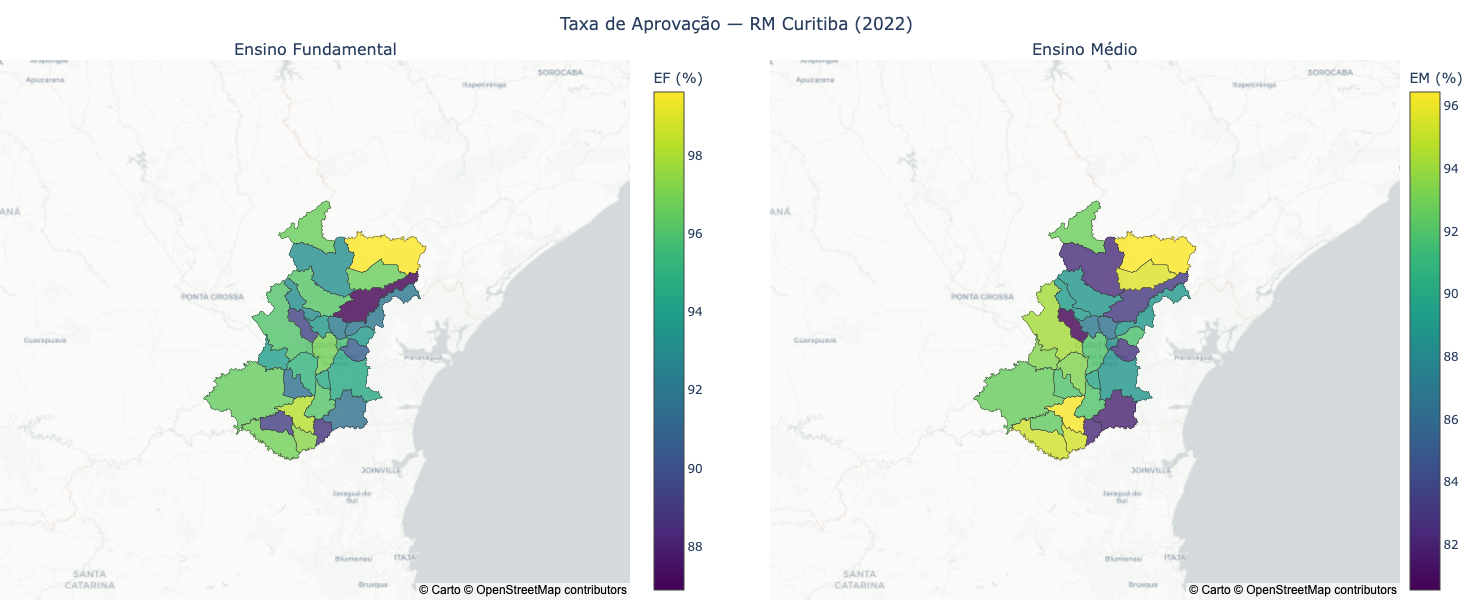

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

minx, miny, maxx, maxy = mapa_rmc.total_bounds
centro_lat = (miny + maxy) / 2
centro_lon = (minx + maxx) / 2

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'choroplethmapbox'}, {'type': 'choroplethmapbox'}]],
    subplot_titles=('Ensino Fundamental', 'Ensino Médio')
)

fig.add_trace(go.Choroplethmapbox(
    geojson=geojson_rmc,
    locations=mapa_rmc.index,
    z=mapa_rmc['taxa_aprovacao_ef'],
    colorscale='Viridis',
    marker_opacity=0.8,
    marker_line_width=0.5,
    customdata=mapa_rmc[['nome', 'taxa_aprovacao_ef']],
    hovertemplate='<b>%{customdata[0]}</b><br>Aprovação EF: %{customdata[1]:.1f}%<extra></extra>',
    colorbar=dict(title='EF (%)', x=0.46),
    subplot='mapbox'
), row=1, col=1)

fig.add_trace(go.Choroplethmapbox(
    geojson=geojson_rmc,
    locations=mapa_rmc.index,
    z=mapa_rmc['taxa_aprovacao_em'],
    colorscale='Viridis',
    marker_opacity=0.8,
    marker_line_width=0.5,
    customdata=mapa_rmc[['nome', 'taxa_aprovacao_em']],
    hovertemplate='<b>%{customdata[0]}</b><br>Aprovação EM: %{customdata[1]:.1f}%<extra></extra>',
    colorbar=dict(title='EM (%)', x=1.0),
    subplot='mapbox2'
), row=1, col=2)

fig.update_layout(
    mapbox=dict(style='carto-positron', zoom=6.5, center={'lat': centro_lat, 'lon': centro_lon}),
    mapbox2=dict(style='carto-positron', zoom=6.5, center={'lat': centro_lat, 'lon': centro_lon}),
    margin={'r': 0, 't': 60, 'l': 0, 'b': 0},
    title=f'Taxa de Aprovação — RM Curitiba ({ultimo_ano_mapa})',
    title_x=0.5,
    height=600
)

fig.write_html('mapa_rmc_aprovacao_ef_em_interativo.html')
fig.show()


# Mapa ao longo dos anos

In [32]:
# Reconsultando dados de todos os anos para a RMC (não só o último ano)
dados_rmc_todos_anos = (
    df[df['id_municipio'].astype(str).isin(gdf_rmc['id_municipio'])]
    .groupby(['id_municipio', 'ano'])[['taxa_aprovacao_ef', 'taxa_aprovacao_em']]
    .mean()
    .reset_index()
)
dados_rmc_todos_anos['id_municipio'] = dados_rmc_todos_anos['id_municipio'].astype(str)

anos_disponiveis = sorted(dados_rmc_todos_anos['ano'].unique())
print(f"Anos disponíveis: {anos_disponiveis}")

Anos disponíveis: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022)]


In [33]:
import matplotlib.pyplot as plt
from PIL import Image
import os

os.makedirs('frames_gif', exist_ok=True)

# Escala de cor fixa em todos os frames, para a comparação entre anos ser justa
vmin = dados_rmc_todos_anos[['taxa_aprovacao_ef', 'taxa_aprovacao_em']].min().min()
vmax = dados_rmc_todos_anos[['taxa_aprovacao_ef', 'taxa_aprovacao_em']].max().max()

caminhos_frames = []

for ano in anos_disponiveis:
    dados_ano = dados_rmc_todos_anos[dados_rmc_todos_anos['ano'] == ano]
    mapa_ano = gdf_rmc.merge(dados_ano, on='id_municipio', how='left')
    mapa_ano = mapa_ano.merge(validacao_rmc[['id_municipio', 'nome']], on='id_municipio', how='left')

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    for ax, coluna, titulo in zip(axes, ['taxa_aprovacao_ef', 'taxa_aprovacao_em'],
                                    ['Ensino Fundamental', 'Ensino Médio']):
        mapa_ano.plot(
            column=coluna, ax=ax, cmap='Oranges',
            vmin=vmin, vmax=vmax,
            edgecolor='white', linewidth=0.6,
            legend=True, legend_kwds={'label': 'Taxa de aprovação (%)', 'shrink': 0.6},
            missing_kwds={'color': 'lightgrey', 'label': 'Sem dado'}
        )
        ax.set_title(titulo, fontsize=13, fontweight='bold')
        ax.set_axis_off()

    fig.suptitle(f'Taxa de Aprovação — RM Curitiba ({ano})', fontsize=16, fontweight='bold', y=0.98)
    fig.text(0.5, 0.02, 'Fonte: INEP / Base dos Dados', ha='center', fontsize=9, color='gray')

    caminho = f'frames_gif/frame_{ano}.png'
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(caminho, dpi=120, bbox_inches='tight')
    plt.close(fig)
    caminhos_frames.append(caminho)

print(f"{len(caminhos_frames)} frames gerados")

12 frames gerados


In [34]:
imagens = [Image.open(c) for c in caminhos_frames]

imagens[0].save(
    'evolucao_aprovacao_rmc.gif',
    save_all=True,
    append_images=imagens[1:],
    duration=800,  # milissegundos por frame
    loop=0  # 0 = loop infinito
)

print("GIF salvo: evolucao_aprovacao_rmc.gif")

GIF salvo: evolucao_aprovacao_rmc.gif
